# Samuel - Mejora 10 - Diagnóstico del error y techo de exactitud

**Proyecto - Parte 1: Machine Learning clásico**

**Estudiantes:**

[Nombre integrante 1] – [código]

[Nombre integrante 2] – [código]

**Curso:** ISIS2611 - Aprendizaje de Máquina

---

## Contexto

Después de nueve iteraciones, los modelos del grupo se quedan alrededor de **0,90 de exactitud**: la regresión logística, NB-LR, el modelo en dos etapas, las votaciones, el apilamiento y la compuerta KNN de la Mejora 9 de Samuel terminan todos entre 0,89 y 0,91. Cuando tantas ideas distintas llegan al mismo número, vale la pena preguntarse si el límite está en los modelos o en los datos.

Este notebook **no entrena un modelo nuevo**. Mide, con los errores de NB-LR sobre las 12.000 reseñas etiquetadas, **dónde están los errores y cuáles se pueden corregir**:

1. Clasifica las reseñas en grupos definidos solo con el texto (con cierre de duda, con una opinión, con dos opiniones opuestas…) y reparte los errores entre ellos.
2. Comprueba si en los grupos con más errores la etiqueta se puede predecir a partir del texto, o si se comporta como una moneda al aire.
3. Calcula una **cota superior de exactitud**, con sus supuestos a la vista.
4. Estima cuánto podrían ganar, como máximo, las ideas que quedan por probar.
5. Explica por qué un puntaje público de 0,91 o más no implica que un modelo sea mejor que uno de 0,90.

| Paso | Sección de este notebook |
|:---|:---|
| Datos, partición y preprocesamiento (los mismos de las mejoras anteriores) | 2 y 3 |
| Predicciones fuera de muestra de NB-LR sobre las 12.000 reseñas | 4 |
| Grupos de reseñas y reparto de los errores | 5 |
| ¿El cierre de duda es azar? | 6 |
| Control de validez: reseñas con dos opiniones opuestas | 7 |
| Cota superior de exactitud | 8 |
| Dónde queda margen real | 9 |
| Lectura del puntaje público de Kaggle | 10 |

## Requisitos de la guía

| Requisito | Cómo se cumple |
|:---|:---|
| No usar aprendizaje profundo, transformers ni embeddings preentrenados. | No se usa ninguno. Solo bolsas de palabras, TF-IDF, regresión logística y NB-LR. |
| Usar únicamente modelos de scikit-learn. | Todos los clasificadores son de scikit-learn (`NBRegresionLogistica` es una clase propia que combina `LogisticRegression` con la razón de Naive Bayes). |
| No usar `eval.csv` para entrenar. | Este notebook no lee `eval.csv`. |
| Resultados replicables. | Semillas fijas y todo el flujo en este notebook (sección 13). |

## 1. Importación de librerías

In [1]:
import os
import re
import time
import unicodedata
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse, stats

try:
    from nltk.stem import SnowballStemmer
except ImportError:
    %pip install nltk
    from nltk.stem import SnowballStemmer

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 180)

RANDOM_STATE = 42
ORDEN_CLASES = ['negativo', 'neutral', 'positivo']
INICIO_NOTEBOOK = time.time()

# Rutas del proyecto (este notebook está en la carpeta notebooks/)
RUTA_DATOS = os.path.join('..', 'data')

## 2. Datos y partición

Se usan las 12.000 reseñas etiquetadas de `train.csv`. Para la sección 6 se necesita además la **misma partición 60/20/20 de la Mejora 8 y la Mejora 9 de Samuel** (mismas semillas), que se usa solo para la curva de aprendizaje. Para todo lo demás, cada reseña se evalúa con un modelo que no la vio al entrenarse (sección 4), de modo que las cifras se calculan con las 12.000 reseñas y no con las 2.400 de un solo conjunto de validación.

In [2]:
train = pd.read_csv(os.path.join(RUTA_DATOS, 'train.csv'))
print('train:', train.shape)
display(train['label'].value_counts(normalize=True).reindex(ORDEN_CLASES).round(3).to_frame('proporción'))

X = train[['text']]
y = train['label']
y_arr = y.values

# La misma partición 60/20/20 de la Mejora 8 y la Mejora 9 de Samuel
X_resto, X_test, y_resto, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_resto, y_resto, test_size=0.25, stratify=y_resto, random_state=RANDOM_STATE)
print('Entrenamiento:', X_train.shape, '| Validación:', X_val.shape, '| Prueba:', X_test.shape)

train: (12000, 3)


,proporción
label,
negativo,0.351
neutral,0.298
positivo,0.351


Entrenamiento: (7200, 1) | Validación: (2400, 1) | Prueba: (2400, 1)


## 3. Preprocesamiento y NB-LR

Se reutilizan, sin cambios, las celdas de la Mejora 8 y la Mejora 9 de Samuel: limpieza del texto, la representación por bloques con la cláusula corregida, las bolsas binarias con marcado de negación y la clase `NBRegresionLogistica` (NB-LR). NB-LR con `C = 0,1` y `alpha = 0,5` es el modelo base del análisis: es rápido y sus errores son casi los mismos que los de los modelos más complejos (en la Mejora 8, el 83% de los errores de la regresión logística también los comete el modelo en dos etapas).

In [3]:
stemmer = SnowballStemmer('spanish')
cache_raices = {}


def raiz(palabra):
    # Se guarda la raíz de cada palabra para no repetir el stemming miles de veces
    if palabra not in cache_raices:
        cache_raices[palabra] = stemmer.stem(palabra)
    return cache_raices[palabra]


def quitar_tildes(texto):
    texto = unicodedata.normalize('NFKD', texto)
    return ''.join(c for c in texto if not unicodedata.combining(c))


def limpiar_texto(texto, stop=None, stemming=True):
    texto = quitar_tildes(texto.lower())
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\d+', ' ', texto)
    tokens = texto.split()
    if stop:
        tokens = [t for t in tokens if t not in stop]
    if stemming:
        tokens = [raiz(t) for t in tokens]
    return ' '.join(tokens)


def separar_oraciones(texto):
    return [o.strip() for o in re.split(r'(?<=[.!?])\s+', texto) if o.strip()]


# Conectores que introducen la opinión que se impone sobre la anterior
CONECTORES = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|a fin de cuentas|al final)\b'


def extraer_completo(textos, stemming=True):
    return [limpiar_texto(t, stemming=stemming) for t in textos]


def extraer_ultima(textos, stemming=True):
    return [limpiar_texto(separar_oraciones(t)[-1], stemming=stemming) for t in textos]


def extraer_clausula_final(textos, stemming=True):
    salida = []
    for t in textos:
        ultima = quitar_tildes(separar_oraciones(t)[-1].lower())
        salida.append(limpiar_texto(re.split(CONECTORES, ultima)[-1], stemming=stemming))
    return salida


def bloque_tfidf(nombre, extractor, rango=(1, 2)):
    return (nombre,
            Pipeline([('extraer', FunctionTransformer(extractor)),
                      ('tfidf', TfidfVectorizer(ngram_range=rango))]),
            'text')


def construir_representacion(bloques=('completo', 'ultima', 'clausula'), rango=(1, 2)):
    extractores = {'completo': extraer_completo,
                   'ultima': extraer_ultima,
                   'clausula': extraer_clausula_final}
    return ColumnTransformer([bloque_tfidf(b, extractores[b], rango) for b in bloques])

In [4]:
# "al final de cuentas" y "a fin de cuentas" suelen ser muletillas al final de la frase, no conectores.
# Se deja de cortar ahí y, si el corte deja un fragmento de menos de 3 palabras, se toma el anterior.
CONECTORES_CORREGIDOS = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|al final(?! de cuentas))\b'


def ultimo_fragmento(oracion, min_palabras=3):
    partes = [p for p in re.split(CONECTORES_CORREGIDOS, quitar_tildes(oracion.lower())) if len(p.split()) >= min_palabras]
    return partes[-1] if partes else oracion


def extraer_clausula_corregida(textos, stemming=True):
    return [limpiar_texto(ultimo_fragmento(separar_oraciones(t)[-1]), stemming=stemming) for t in textos]


def construir_representacion_corregida(rango=(1, 2)):
    return ColumnTransformer([bloque_tfidf('completo', extraer_completo, rango),
                              bloque_tfidf('ultima', extraer_ultima, rango),
                              bloque_tfidf('clausula', extraer_clausula_corregida, rango)])

In [5]:
def construir_bolsas_binarias(rango=(1, 2)):
    # Los mismos tres bloques del notebook principal, pero con presencia/ausencia de cada n-grama en lugar de TF-IDF
    extractores = {'completo': extraer_completo, 'ultima': extraer_ultima, 'clausula': extraer_clausula_corregida}
    return ColumnTransformer([
        (nombre, Pipeline([('extraer', FunctionTransformer(extractor)),
                           ('conteo', CountVectorizer(ngram_range=rango, binary=True))]), 'text')
        for nombre, extractor in extractores.items()
    ])


class NBRegresionLogistica(ClassifierMixin, BaseEstimator):
    """Regresión logística sobre atributos ponderados con la razón de Naive Bayes (NB-LR).

    Para cada clase (una contra el resto) cada atributo se multiplica por
    log(P(atributo | clase) / P(atributo | resto)), calculado con suavizado alpha como en
    MultinomialNB, y sobre esos atributos se entrena una regresión logística.
    """

    def __init__(self, C=0.3, alpha=1.0):
        self.C = C
        self.alpha = alpha

    def fit(self, X, y):
        X = sparse.csr_matrix(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.razones_, self.modelos_ = [], []
        for clase in self.classes_:
            es_clase = y == clase
            p = self.alpha + np.asarray(X[es_clase].sum(axis=0)).ravel()
            q = self.alpha + np.asarray(X[~es_clase].sum(axis=0)).ravel()
            razon = np.log((p / p.sum()) / (q / q.sum()))
            modelo = LogisticRegression(C=self.C, max_iter=3000)
            modelo.fit(X.multiply(razon).tocsr(), es_clase.astype(int))
            self.razones_.append(razon)
            self.modelos_.append(modelo)
        return self

    def predict_proba(self, X):
        X = sparse.csr_matrix(X, dtype=float)
        P = np.column_stack([m.predict_proba(X.multiply(r).tocsr())[:, 1]
                             for m, r in zip(self.modelos_, self.razones_)])
        return P / P.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]


# Marcado del alcance de la negación (Mejora 5 de la rama pruebas1) sobre la cláusula corregida
NEGADORES = {'no', 'nunca', 'jamas', 'tampoco', 'ni', 'sin'}


def marcar_negacion(fragmento):
    salida = []
    for clausula in re.split(r'[.,;:!?()]+|' + CONECTORES_CORREGIDOS, fragmento):
        pieza = re.sub(r'\d+', ' ', re.sub(r'[^\w\s]', ' ', clausula))
        negando = False
        for palabra in pieza.split():
            if palabra in NEGADORES:
                negando = True
                salida.append(raiz(palabra))
                continue
            salida.append(raiz(palabra) + '_neg' if negando else raiz(palabra))
    return ' '.join(salida)


def extraer_ultima_negacion(textos):
    return [marcar_negacion(quitar_tildes(separar_oraciones(t)[-1].lower())) for t in textos]


def extraer_clausula_corregida_negacion(textos):
    return [marcar_negacion(ultimo_fragmento(separar_oraciones(t)[-1])) for t in textos]


def bolsas_binarias_negacion():
    extractores = {'completo': extraer_completo, 'ultima': extraer_ultima_negacion,
                   'clausula': extraer_clausula_corregida_negacion}
    return ColumnTransformer([
        (nombre, Pipeline([('extraer', FunctionTransformer(extractor)),
                           ('conteo', CountVectorizer(ngram_range=(1, 2), binary=True))]), 'text')
        for nombre, extractor in extractores.items()
    ])

## 4. Predicciones fuera de muestra sobre las 12.000 reseñas

Para saber dónde falla NB-LR sobre **todas** las reseñas, cada una se predice con un modelo que no la vio: validación cruzada estratificada de 5 particiones (`cross_val_predict`), repetida con 3 semillas. Para cada reseña se guarda la **fracción de las 3 repeticiones en que falla** (0, 1/3, 2/3 o 1); la exactitud de un grupo es uno menos el promedio de esa fracción, y los errores esperados son su suma.

In [6]:
def nblr():
    return Pipeline([('rep', bolsas_binarias_negacion()), ('modelo', NBRegresionLogistica(C=0.1, alpha=0.5))])


SEMILLAS = [42, 1, 2]
inicio = time.time()
pred_semillas = []
for semilla in SEMILLAS:
    particiones = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)
    pred_semillas.append(cross_val_predict(nblr(), X, y, cv=particiones, n_jobs=-1))
print(f'Predicciones fuera de muestra: {time.time() - inicio:.0f} s')

exactitudes = [(p == y_arr).mean() for p in pred_semillas]
print('Exactitud fuera de muestra por semilla:', dict(zip(SEMILLAS, np.round(exactitudes, 4))), '| promedio:', round(np.mean(exactitudes), 4))

error_resena = np.mean([p != y_arr for p in pred_semillas], axis=0)       # fracción de semillas en que falla cada reseña
print(f'Errores esperados sobre las {len(y_arr):,} reseñas: {error_resena.sum():.0f} ({error_resena.mean():.2%})'.replace(',', '.'))

Predicciones fuera de muestra: 12 s
Exactitud fuera de muestra por semilla: {42: np.float64(0.8996), 1: np.float64(0.8988), 2: np.float64(0.9015)} | promedio: 0.8999
Errores esperados sobre las 12.000 reseñas: 1201 (10.01%)


## 5. Grupos de reseñas y reparto de los errores

Los grupos se definen **solo con el texto** (nunca con la etiqueta), para que la clasificación se pueda aplicar a reseñas nuevas:

- **Cierre neutro:** la última oración es "nada más que agregar/comentar/contar…". Casi siempre son reseñas neutrales.
- **Cierre de duda:** la última oración es una frase que se repite al menos 10 veces en `train.csv` ("cada quien que juzgue", "ni fu ni fa", "sigo con dudas la verdad"…) **o** contiene una de las fórmulas de esas frases ("sigo con dudas", "no me decido", "sentimientos encontrados", "a tu criterio", "cada quien", "ni lo mejor ni lo peor", "ni tan bueno", "qué recomendar", "sopésalo", "hay de todo"…, o un "ahí lo dejo" en una oración corta). La segunda condición atrapa las variantes que no se repiten tal cual porque tienen una cláusula de más o un error de ortografía. Se evitan a propósito palabras sueltas como "duda" o "lo dejo", que también aparecen en oraciones que no son un cierre ("llamé por una duda de configuración", "lo dejo cargando"); la celda de auditoría muestra ejemplos para que se pueda revisar la regla.
- **Sin opinión / una opinión / dos opiniones opuestas / otras:** para el resto se cuentan las oraciones con opinión. Un clasificador de oraciones (TF-IDF y regresión logística, cada oración con la etiqueta de su reseña, como en la etapa 1 de la Mejora 1) puntúa cada oración **fuera de muestra**, y se considera que una oración tiene opinión si su probabilidad de neutral es menor que 0,5 y la diferencia entre sus probabilidades de positivo y negativo supera un umbral (0,3 por defecto; en la sección 7 se varía).

In [7]:
def normalizar(texto):
    texto = unicodedata.normalize('NFKD', texto.lower()).encode('ascii', 'ignore').decode()
    return re.sub(r'\s+', ' ', re.sub(r'[^\w\s]', ' ', texto)).strip()


oraciones = [separar_oraciones(t) for t in train['text']]
oraciones_norm = [[normalizar(o) for o in lista] for lista in oraciones]
ultima = [lista[-1] for lista in oraciones_norm]
frecuencia_ultima = Counter(ultima)

CIERRE_NEUTRO = re.compile(r'\bnada mas que (agregar|comentar|contar)\b')
FORMULAS_DUDA = re.compile(r'\b(sigo con (la )?dudas?|ando con dudas|en la duda|misma duda|sin decidirme|no me decido|no he decidido|'
                           r'sentimientos encontrados|a (tu )?criterio|cada quien|juzgue\w*|para gustos|ni fu|ni lo mejor|ni lo peor|'
                           r'ni tan bueno|que recomendar|sus conclusiones|sopes\w*|hay de todo|queda mi valoracion|ahi queda)\b')


def es_formula_de_duda(oracion):
    return bool(FORMULAS_DUDA.search(oracion)) or ('ahi lo dejo' in oracion and len(oracion.split()) <= 5)


es_cierre_neutro = np.array([bool(CIERRE_NEUTRO.search(u)) for u in ultima])
repetido = np.array([frecuencia_ultima[u] >= 10 for u in ultima])
es_cierre_duda = np.array([(not neutro) and (rep or es_formula_de_duda(u))
                           for u, neutro, rep in zip(ultima, es_cierre_neutro, repetido)])
solo_formula = es_cierre_duda & ~repetido
print(f'Cierre neutro: {es_cierre_neutro.sum()} reseñas | cierre de duda: {es_cierre_duda.sum()} reseñas '
      f'({(es_cierre_duda & repetido).sum()} por frase repetida y {solo_formula.sum()} solo por fórmula)')

# Las frases de cierre de duda más repetidas y la mezcla de etiquetas del grupo
cierres = pd.Series(np.array(ultima, dtype=object)[es_cierre_duda]).value_counts()
print('\nFrases de cierre de duda más repetidas:')
display(cierres.head(12).to_frame('veces'))
print(f'Frases distintas en el grupo: {len(cierres)} | las que aparecen una sola vez (variantes): {(cierres == 1).sum()}')
display(y[es_cierre_duda].value_counts().reindex(ORDEN_CLASES).to_frame('reseñas con cierre de duda'))

# Auditoría de la regla: 30 últimas oraciones al azar de las reseñas que entran SOLO por la fórmula (no por repetirse)
print('\nAuditoría: últimas oraciones de reseñas que entran al grupo solo por la fórmula (etiqueta entre corchetes):')
for i in np.random.default_rng(2).choice(np.flatnonzero(solo_formula), size=30, replace=False):
    print(f'  [{y_arr[i][:3]}] {ultima[i]}')
neutrales_formula = int((solo_formula & (y_arr == 'neutral')).sum())
print(f'\nReseñas neutrales que entran solo por la fórmula (posibles falsos positivos): {neutrales_formula} de {int(solo_formula.sum())}')

Cierre neutro: 240 reseñas | cierre de duda: 1456 reseñas (975 por frase repetida y 481 solo por fórmula)

Frases de cierre de duda más repetidas:


,veces
cada quien que juzgue,121
para gustos colores,90
sigo con dudas la verdad,82
en fin ni fu ni fa,75
queda a criterio de cada uno,66
no sabria bien que recomendar,64
hay de todo como se ve,63
sopesalo tu mismo,60
lo dejo a tu criterio,56
todavia no me decido,55


Frases distintas en el grupo: 411 | las que aparecen una sola vez (variantes): 346


,reseñas con cierre de duda
label,
negativo,737
neutral,13
positivo,706



Auditoría: últimas oraciones de reseñas que entran al grupo solo por la fórmula (etiqueta entre corchetes):
  [neg] cada quien sopeselo usted mismo
  [neg] todavia no me decido si quedarmela o devolverla
  [pos] ahi queda la cosa
  [neg] ni lo mejor ni lo peor asi que ahi sigo pensando que tal me sigue pareciendo
  [pos] todavia no me decido si lo dejo o lo cambio
  [neg] todavia no me decido si quedarme con el o no
  [neg] cada quien lo soopese por su cuenta
  [pos] la verdad sigo con dudas
  [neg] ni tan bueno ni tan malo la verdad sigo pensandolo
  [neg] asi que ahi lo dejo cada quien sacara sus conclusiones
  [pos] tengo sentimientos encontrados con el tema
  [pos] en fin para gustos colores
  [neg] ni tan bueno ni tan malo al final
  [pos] del material no digo ni lo mejor ni lo peor es lo que hay
  [neg] ahi lo dejo cada quien saca sus conclusiones
  [pos] la verdad es que tengo sentimientos encontrados con la compra
  [pos] ni lo mejor ni lo peor la uso igual casi a diario
  [po

In [8]:
def puntuar_oraciones_fuera_de_muestra(semilla=0):
    """Para cada oración de cada reseña: P(positivo) - P(negativo) y P(neutral), con un clasificador de oraciones
    entrenado en las otras 4 de las 5 particiones (cada oración hereda la etiqueta de su reseña)."""
    polaridad, neutral = [None] * len(oraciones), [None] * len(oraciones)
    for idx_ent, idx_fuera in KFold(n_splits=5, shuffle=True, random_state=semilla).split(np.arange(len(oraciones))):
        textos = [o for i in idx_ent for o in oraciones_norm[i]]
        etiquetas = [y_arr[i] for i in idx_ent for _ in oraciones_norm[i]]
        vectorizador = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
        clasificador = LogisticRegression(C=3, max_iter=2000).fit(vectorizador.fit_transform(textos), etiquetas)
        clases = list(clasificador.classes_)
        for i in idx_fuera:
            P = clasificador.predict_proba(vectorizador.transform(oraciones_norm[i]))
            polaridad[i] = P[:, clases.index('positivo')] - P[:, clases.index('negativo')]
            neutral[i] = P[:, clases.index('neutral')]
    return polaridad, neutral


inicio = time.time()
polaridad_oracion, neutral_oracion = puntuar_oraciones_fuera_de_muestra()
print(f'Oraciones puntuadas fuera de muestra: {time.time() - inicio:.0f} s | oraciones en total: {sum(len(p) for p in polaridad_oracion):,}'.replace(',', '.'))


def indices_con_opinion(i, umbral=0.3):
    return [j for j in range(len(polaridad_oracion[i])) if neutral_oracion[i][j] < 0.5 and abs(polaridad_oracion[i][j]) > umbral]


def tipo_de_opiniones(i, umbral=0.3):
    idx = indices_con_opinion(i, umbral)
    if len(idx) == 0:
        return 'Sin opinión detectada'
    if len(idx) == 1:
        return 'Una opinión'
    if len(idx) == 2 and np.sign(polaridad_oracion[i][idx[0]]) != np.sign(polaridad_oracion[i][idx[1]]):
        return 'Dos opiniones opuestas'
    return 'Otras (2 del mismo signo o 3 o más)'

Oraciones puntuadas fuera de muestra: 26 s | oraciones en total: 46.694


,Reseñas,% de las reseñas,% neutrales,Exactitud,IC 95% bajo,IC 95% alto,Errores esperados,% de los errores
Grupo,,,,,,,,
Cierre neutro,240,2.000,96.667,0.979,0.952,0.991,5.000,0.416
Sin opinión detectada,3936,32.800,67.403,0.974,0.968,0.978,104.000,8.662
Una opinión,3327,27.725,18.485,0.940,0.931,0.947,200.000,16.657
Dos opiniones opuestas,1060,8.833,2.736,0.936,0.920,0.950,67.333,5.608
Otras (2 del mismo signo o 3 o más),1981,16.508,1.716,0.931,0.919,0.942,136.000,11.327
Cierre de duda,1456,12.133,0.893,0.527,0.502,0.553,688.333,57.329


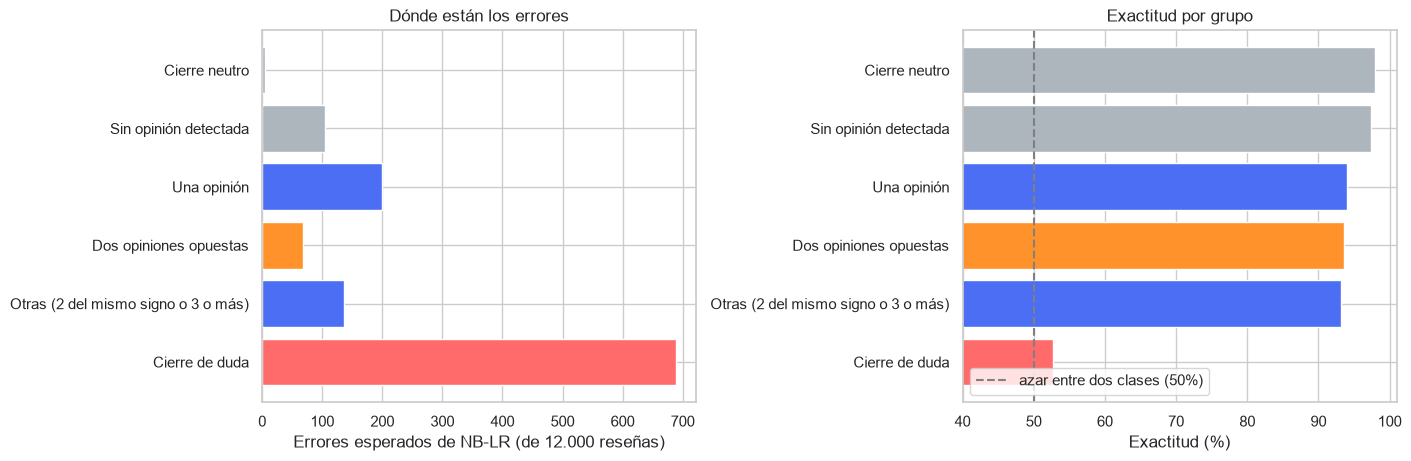

In [9]:
def wilson(aciertos, n, z=1.96):
    p = aciertos / n
    denominador = 1 + z ** 2 / n
    centro = (p + z ** 2 / (2 * n)) / denominador
    margen = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denominador
    return centro - margen, centro + margen


grupo = np.where(es_cierre_neutro, 'Cierre neutro', np.where(es_cierre_duda, 'Cierre de duda', '')).astype(object)
for i in np.flatnonzero(grupo == ''):
    grupo[i] = tipo_de_opiniones(i)
grupo = pd.Series(grupo, index=train.index)

ORDEN_GRUPOS = ['Cierre neutro', 'Sin opinión detectada', 'Una opinión', 'Dos opiniones opuestas', 'Otras (2 del mismo signo o 3 o más)', 'Cierre de duda']
filas = []
for nombre in ORDEN_GRUPOS:
    m = (grupo == nombre).values
    n, errores = int(m.sum()), error_resena[m].sum()
    bajo, alto = wilson(n - errores, n)
    filas.append({'Grupo': nombre, 'Reseñas': n, '% de las reseñas': 100 * n / len(grupo), '% neutrales': 100 * (y_arr[m] == 'neutral').mean(),
                  'Exactitud': 1 - errores / n, 'IC 95% bajo': bajo, 'IC 95% alto': alto,
                  'Errores esperados': errores, '% de los errores': 100 * errores / error_resena.sum()})
tabla_grupos = pd.DataFrame(filas).set_index('Grupo')
display(tabla_grupos.round(3))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
colores = ['#ADB5BD', '#ADB5BD', '#4C6EF5', '#FF922B', '#4C6EF5', '#FF6B6B']
ax[0].barh(tabla_grupos.index, tabla_grupos['Errores esperados'], color=colores)
ax[0].invert_yaxis()
ax[0].set(xlabel='Errores esperados de NB-LR (de 12.000 reseñas)', title='Dónde están los errores')
ax[1].barh(tabla_grupos.index, 100 * tabla_grupos['Exactitud'], color=colores)
ax[1].axvline(50, color='gray', linestyle='--', label='azar entre dos clases (50%)')
ax[1].invert_yaxis()
ax[1].set(xlabel='Exactitud (%)', xlim=(40, 101), title='Exactitud por grupo')
ax[1].legend(loc='lower left')
plt.show()

**Dónde están los errores.** NB-LR acierta el 0,8999 de las 12.000 reseñas fuera de muestra (1.201 errores esperados). Los grupos se reparten así:

- **El cierre de duda es el 12,1% de las reseñas y produce el 57,3% de los errores** (688 de 1.201). Es el único grupo en que NB-LR acierta cerca de la mitad (0,527, con intervalo de 0,502 a 0,553), y casi no tiene reseñas neutrales (13 de 1.456). Los 5,7 puntos de error que aporta son más de la mitad de los 10 puntos de error totales.
- **Todos los demás grupos tienen exactitud de 0,93 a 0,98.** Las reseñas con una opinión (0,940), con dos opiniones opuestas (0,936) y con otras combinaciones (0,931) pierden entre 0,6 y 1,7 puntos cada una; las reseñas en las que no se detectó opinión (0,974; dos de cada tres son neutrales) y los cierres neutros (0,979) pierden menos. No hay un grupo concentrado, con una tasa de error alta, que sirva como blanco fácil.
- **La regla del cierre de duda es razonable.** La mayor parte del grupo (975 reseñas) entra porque su última oración es una frase que se repite 10 veces o más; las otras 481 entran por tener las mismas fórmulas con una cláusula de más o un error de ortografía (en la auditoría se ven "ni tan bueno ni tan malo la verdad sigo pensandolo", "cada quien lo soopese por su cuenta"). Solo 13 de esas 481 son neutrales, que serían los falsos positivos más claros. Las reseñas positivas y negativas se reparten casi por igual (737 y 706).

## 6. ¿El cierre de duda es azar?

En el grupo con cierre de duda (casi todo positivas y negativas, sin neutrales) NB-LR acierta cerca de la mitad. Hay dos explicaciones posibles: que el modelo no sea lo bastante bueno, o que **el texto no contenga la información** para decidir. Se separan con cuatro pruebas:

1. **Balance de clases y exactitud frente al azar:** si la etiqueta es una moneda al aire, el grupo está dividido en mitades y el modelo acierta cerca del 50% (prueba binomial).
2. **Un modelo entrenado solo para este problema.** Muchas de estas reseñas tienen dos opiniones opuestas (una buena y una mala) más el cierre de duda, y la pregunta es cuál de las dos define la etiqueta. Se entrena una regresión logística que, con el texto de las dos opiniones y sus posiciones, predice si **gana la primera** o la última, con validación cruzada. Si hubiera una regla en el texto, este modelo la encontraría.
3. **Un especialista entrenado solo con este grupo.** Si NB-LR falla porque el grupo es distinto al resto y se mezcla con él, un modelo entrenado únicamente con estas reseñas (con el texto completo, sin la oración de cierre, o solo con la estructura de la reseña) debería encontrar la señal.
4. **Curva de aprendizaje:** si la exactitud del grupo no sube al darle más reseñas de entrenamiento al modelo, no hay nada que aprender; en el resto de las reseñas positivas y negativas sí debería subir.

In [10]:
m_duda = es_cierre_duda
n_duda = int(m_duda.sum())
n_neg = int((y_arr[m_duda] == 'negativo').sum())
n_pos = int((y_arr[m_duda] == 'positivo').sum())
print(f'Cierre de duda: {n_duda} reseñas -> negativas {n_neg}, positivas {n_pos}, neutrales {n_duda - n_neg - n_pos}')
print(f'  prueba binomial de que la proporción de negativas es 0,5: p = {stats.binomtest(n_neg, n_neg + n_pos, 0.5).pvalue:.3f}')

polares_duda = m_duda & (y_arr != 'neutral')
aciertos = int(round((1 - error_resena[polares_duda]).sum()))
n_polares = int(polares_duda.sum())
bajo, alto = wilson(aciertos, n_polares)
print(f'\nExactitud de NB-LR en las reseñas positivas/negativas con cierre de duda: {aciertos / n_polares:.3f} '
      f'(IC 95%: {bajo:.3f} a {alto:.3f}, n = {n_polares})')
print(f'  prueba binomial contra 0,5: p = {stats.binomtest(aciertos, n_polares, 0.5).pvalue:.3f}')
mayoria = max(n_neg, n_pos) / (n_neg + n_pos)
print(f'  contestar siempre la clase más frecuente del grupo acertaría {mayoria:.3f}')

Cierre de duda: 1456 reseñas -> negativas 737, positivas 706, neutrales 13
  prueba binomial de que la proporción de negativas es 0,5: p = 0.430

Exactitud de NB-LR en las reseñas positivas/negativas con cierre de duda: 0.523 (IC 95%: 0.497 a 0.549, n = 1443)
  prueba binomial contra 0,5: p = 0.082
  contestar siempre la clase más frecuente del grupo acertaría 0.511


In [11]:
def pares_de_opiniones(mascara, umbral=0.3):
    """Reseñas del grupo con exactamente dos opiniones de signo opuesto: texto de cada una, posiciones y quién gana."""
    filas = []
    for i in np.flatnonzero(mascara & (y_arr != 'neutral')):
        idx = indices_con_opinion(i, umbral)
        if len(idx) == 2 and np.sign(polaridad_oracion[i][idx[0]]) != np.sign(polaridad_oracion[i][idx[1]]):
            etiqueta = 1 if y_arr[i] == 'positivo' else -1
            filas.append({'i': i, 'primera': oraciones_norm[i][idx[0]], 'segunda': oraciones_norm[i][idx[1]],
                          'pos1': idx[0], 'pos2': idx[1], 'n_oraciones': len(oraciones_norm[i]),
                          'signo1': np.sign(polaridad_oracion[i][idx[0]]), 'gana_primera': int(np.sign(polaridad_oracion[i][idx[0]]) == etiqueta)})
    return pd.DataFrame(filas)


def modelo_de_quien_gana(pares):
    """Regresión logística que predice si gana la primera opinión, con el texto de ambas opiniones y sus posiciones."""
    v1, v2 = TfidfVectorizer(ngram_range=(1, 2), min_df=2), TfidfVectorizer(ngram_range=(1, 2), min_df=2)
    atributos = sparse.hstack([v1.fit_transform(pares['primera']), v2.fit_transform(pares['segunda']),
                               sparse.csr_matrix(pares[['pos1', 'pos2', 'n_oraciones', 'signo1']].values.astype(float))]).tocsr()
    pred = cross_val_predict(LogisticRegression(C=1, max_iter=3000), atributos, pares['gana_primera'],
                             cv=StratifiedKFold(5, shuffle=True, random_state=1))
    return (pred == pares['gana_primera']).mean()


pares_duda = pares_de_opiniones(m_duda)
exactitud_gana = modelo_de_quien_gana(pares_duda)
base = max(pares_duda['gana_primera'].mean(), 1 - pares_duda['gana_primera'].mean())
bajo, alto = wilson(round(exactitud_gana * len(pares_duda)), len(pares_duda))
print(f'Cierre de duda con exactamente dos opiniones opuestas: {len(pares_duda)} reseñas')
print(f'  gana la primera opinión en el {pares_duda["gana_primera"].mean():.3f} de los casos')
print(f'  si la primera es negativa: {pares_duda[pares_duda.signo1 < 0]["gana_primera"].mean():.3f} (n = {(pares_duda.signo1 < 0).sum()}) | '
      f'si es positiva: {pares_duda[pares_duda.signo1 > 0]["gana_primera"].mean():.3f} (n = {(pares_duda.signo1 > 0).sum()})')
print(f'  modelo entrenado para adivinar quién gana: exactitud {exactitud_gana:.3f} (IC 95%: {bajo:.3f} a {alto:.3f}) | contestar siempre la mayoría: {base:.3f}')

Cierre de duda con exactamente dos opiniones opuestas: 284 reseñas
  gana la primera opinión en el 0.500 de los casos
  si la primera es negativa: 0.496 (n = 137) | si es positiva: 0.503 (n = 147)
  modelo entrenado para adivinar quién gana: exactitud 0.472 (IC 95%: 0.415 a 0.530) | contestar siempre la mayoría: 0.500


In [12]:
# Especialista: regresión logística entrenada SOLO con las reseñas positivas/negativas de cierre de duda (validación cruzada, 3 semillas)
grupo_duda = np.flatnonzero(polares_duda)
y_duda = (y_arr[grupo_duda] == 'positivo').astype(int)
textos_completos = [normalizar(train['text'].iloc[i]) for i in grupo_duda]
textos_sin_cierre = [' '.join(oraciones_norm[i][:-1]) for i in grupo_duda]
estructura = np.array([[len(oraciones_norm[i]), len(train['text'].iloc[i]), len(train['text'].iloc[i].split())] for i in grupo_duda], dtype=float)
estructura = (estructura - estructura.mean(axis=0)) / estructura.std(axis=0)

filas = [{'Atributos del especialista': 'Siempre la clase más frecuente del grupo', 'C': np.nan, 'Exactitud (CV)': max(y_duda.mean(), 1 - y_duda.mean())}]
for nombre, textos in [('Texto completo (palabras y pares de palabras)', textos_completos), ('Texto sin la oración de cierre', textos_sin_cierre)]:
    matriz = TfidfVectorizer(ngram_range=(1, 2), min_df=2).fit_transform(textos)
    for C in [0.1, 1, 10]:
        exactitudes_esp = [(cross_val_predict(LogisticRegression(C=C, max_iter=3000), matriz, y_duda,
                                              cv=StratifiedKFold(5, shuffle=True, random_state=s)) == y_duda).mean() for s in range(3)]
        filas.append({'Atributos del especialista': nombre, 'C': C, 'Exactitud (CV)': np.mean(exactitudes_esp)})
exactitudes_esp = [(cross_val_predict(LogisticRegression(max_iter=3000), estructura, y_duda,
                                      cv=StratifiedKFold(5, shuffle=True, random_state=s)) == y_duda).mean() for s in range(3)]
filas.append({'Atributos del especialista': 'Solo número de oraciones y longitud de la reseña', 'C': np.nan, 'Exactitud (CV)': np.mean(exactitudes_esp)})
print(f'Especialista entrenado solo con las {len(grupo_duda)} reseñas positivas/negativas de cierre de duda:')
display(pd.DataFrame(filas).set_index(['Atributos del especialista', 'C']).round(3))
print('Correlación entre el id de la reseña y la etiqueta en el grupo:', round(float(np.corrcoef(train['id'].iloc[grupo_duda], y_duda)[0, 1]), 3))

Especialista entrenado solo con las 1443 reseñas positivas/negativas de cierre de duda:


Exactitud (CV)
Atributos del especialista                       C                   
Siempre la clase más frecuente del grupo         NaN            0.511
Texto completo (palabras y pares de palabras)    0.1            0.519
                                                 1.0            0.516
                                                 10.0           0.508
Texto sin la oración de cierre                   0.1            0.529
                                                 1.0            0.528
                                                 10.0           0.521
Solo número de oraciones y longitud de la reseña NaN            0.486

Correlación entre el id de la reseña y la etiqueta en el grupo: 0.013


Curva de aprendizaje: 13 s | reseñas evaluadas: cierre de duda 586, resto de positivas y negativas 2792


mean                                           std                               
grupo                    Cierre de duda Resto de positivas y negativas Cierre de duda Resto de positivas y negativas
reseñas de entrenamiento                                                                                            
720                               0.515                          0.753          0.012                          0.006
1800                              0.510                          0.881          0.007                          0.007
3600                              0.505                          0.914          0.033                          0.004
7200                              0.534                          0.923            NaN                            NaN

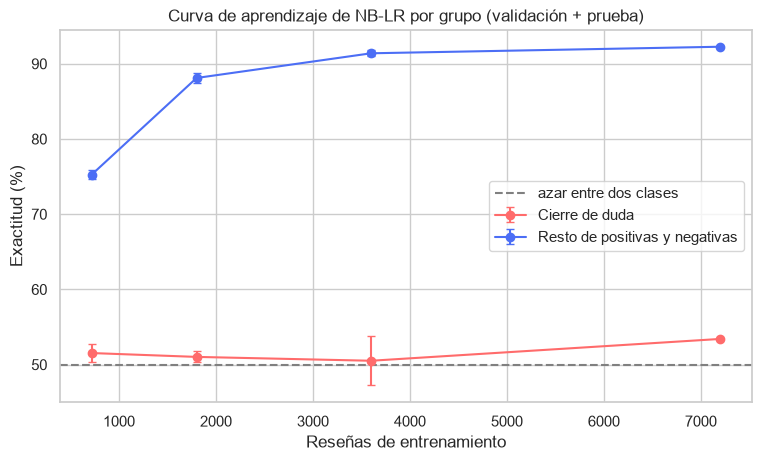

In [13]:
# Curva de aprendizaje: exactitud en el grupo de cierre de duda y en el resto de las positivas/negativas,
# evaluada sobre validación + prueba (4.800 reseñas) con modelos entrenados con una fracción del entrenamiento
pool = X_val.index.union(X_test.index)
y_pool = y.loc[pool].values
grupo_pool = np.where(es_cierre_duda[pool], 'Cierre de duda', np.where(y_pool != 'neutral', 'Resto de positivas y negativas', 'Neutrales'))

fracciones = [0.1, 0.25, 0.5, 1.0]
filas = []
inicio = time.time()
for fraccion in fracciones:
    for repeticion in range(1 if fraccion == 1.0 else 3):
        subconjunto = X_train.sample(frac=fraccion, random_state=repeticion)
        modelo = nblr().fit(subconjunto, y_train.loc[subconjunto.index])
        acierta = modelo.predict(X.loc[pool]) == y_pool
        for g in ['Cierre de duda', 'Resto de positivas y negativas']:
            filas.append({'fracción': fraccion, 'reseñas de entrenamiento': len(subconjunto), 'grupo': g, 'exactitud': acierta[grupo_pool == g].mean()})
curva = pd.DataFrame(filas)
print(f'Curva de aprendizaje: {time.time() - inicio:.0f} s | reseñas evaluadas: cierre de duda {int((grupo_pool == "Cierre de duda").sum())}, '
      f'resto de positivas y negativas {int((grupo_pool == "Resto de positivas y negativas").sum())}')
resumen = curva.groupby(['grupo', 'reseñas de entrenamiento'])['exactitud'].agg(['mean', 'std']).round(3)
display(resumen.unstack(0))

fig, ax = plt.subplots(figsize=(7.5, 4.5), constrained_layout=True)
for g, color in [('Cierre de duda', '#FF6B6B'), ('Resto de positivas y negativas', '#4C6EF5')]:
    d = curva[curva.grupo == g].groupby('reseñas de entrenamiento')['exactitud'].agg(['mean', 'std']).fillna(0)
    ax.errorbar(d.index, 100 * d['mean'], yerr=100 * d['std'], marker='o', color=color, label=g, capsize=3)
ax.axhline(50, color='gray', linestyle='--', label='azar entre dos clases')
ax.set(xlabel='Reseñas de entrenamiento', ylabel='Exactitud (%)', title='Curva de aprendizaje de NB-LR por grupo (validación + prueba)')
ax.legend(loc='center right')
plt.show()

Las cuatro pruebas dicen lo mismo: **en las reseñas con cierre de duda, el texto no contiene lo necesario para decidir la etiqueta**.

1. **Balance de clases y exactitud.** El grupo está dividido en 737 negativas y 706 positivas (compatible con 50/50, p = 0,43). NB-LR acierta el 0,523 de ellas (intervalo de 0,497 a 0,549), frente a 0,511 de contestar siempre la clase más frecuente; contra el azar puro (0,5) no es una diferencia significativa (p = 0,08).
2. **Quién gana entre dos opiniones opuestas.** En las 284 reseñas del grupo con exactamente dos opiniones de signo contrario, gana la primera en el 50,0% de los casos (49,6% si la primera es negativa y 50,3% si es positiva). Un modelo entrenado para adivinar cuál gana, con el texto de las dos opiniones y sus posiciones, acierta 0,472 (intervalo de 0,415 a 0,530), por debajo de contestar siempre la mayoría (0,500).
3. **Un especialista entrenado solo con el grupo.** Con las 1.443 reseñas positivas y negativas del cierre de duda, una regresión logística obtiene entre 0,51 y 0,53 (la clase más frecuente da 0,511) con el texto completo o sin la oración de cierre, y 0,49 con solo el número de oraciones y la longitud. Tampoco hay relación entre el identificador de la reseña y su etiqueta. Es decir, ni mezclando este grupo con el resto ni separándolo hay señal que aprender.
4. **Curva de aprendizaje.** Al pasar de 720 a 7.200 reseñas de entrenamiento, la exactitud de NB-LR en el resto de las reseñas positivas y negativas sube de 0,753 a 0,923; en el cierre de duda se queda entre 0,505 y 0,515 con 720, 1.800 y 3.600 reseñas y llega a 0,534 con 7.200, un valor que cabe dentro del error de la medición (586 reseñas evaluadas, error estándar de unos 2 puntos). Diez veces más datos no mejoran lo que no tiene señal.

Con esta evidencia, tratamos el cierre de duda como **azar respecto del texto**: ningún modelo basado en el texto debería superar de forma consistente el 0,51 a 0,53 en ese grupo. Aun así, no se puede descartar una señal pequeña que estas pruebas no alcanzan a ver: con 1.443 reseñas, una exactitud de 0,54 a 0,55 todavía sería compatible con lo medido.

## 7. Control de validez: reseñas con dos opiniones opuestas

La sección 6 depende de un detector de opiniones que **no es perfecto** (se entrenó con etiquetas heredadas de la reseña). Esta sección hace dos controles sobre las reseñas con dos opiniones opuestas, **con** y **sin** cierre de duda:

1. **Endurecer el detector.** Si en un grupo "gana la última opinión" fuera una regla verdadera escondida por un detector ruidoso, al exigir opiniones más claras debería acercarse a 100%.
2. **Comparar con el modelo completo.** Se compara la exactitud de NB-LR en esas reseñas con la regla "gana la última" y con el modelo sencillo de la sección 6 (que solo ve el texto de las dos opiniones). Si NB-LR acierta mucho más que ambos, la etiqueta **sí** sigue regularidades que se pueden aprender y que el modelo sencillo no captura; si todos aciertan lo mismo, no hay nada que aprender.

Reseñas con dos opiniones opuestas  Gana la primera  Gana la última  Exactitud de NB-LR en ellas  Modelo "quién gana" (CV)
Umbral de opinión Grupo                                                                                                                                         
0.3               Sin cierre de duda                                1031            0.335           0.665                        0.935                     0.675
                  Con cierre de duda                                 284            0.500           0.500                        0.512                     0.472
0.5               Sin cierre de duda                                 316            0.266           0.734                        0.930                     0.741
                  Con cierre de duda                                  79            0.532           0.468                        0.451                     0.519
0.7               Sin cierre de duda                                  21            0.238           0.762                        0.984                       NaN

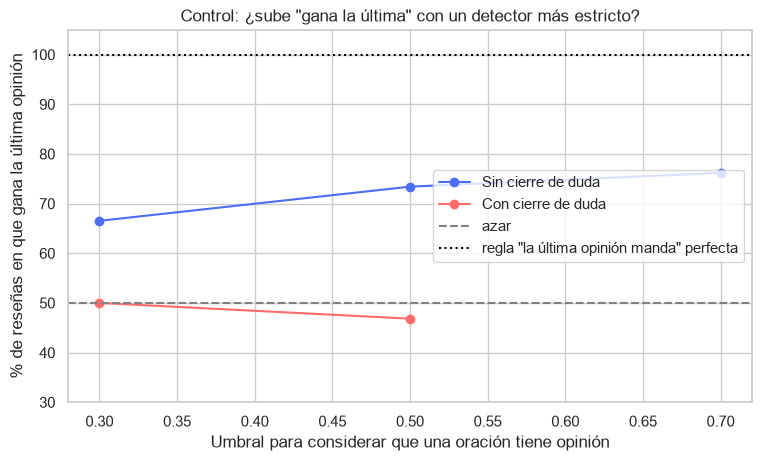

In [14]:
filas = []
acierta_nblr = 1 - error_resena
for umbral in [0.3, 0.5, 0.7, 0.85]:
    for nombre, mascara in [('Sin cierre de duda', ~es_cierre_duda & ~es_cierre_neutro), ('Con cierre de duda', es_cierre_duda)]:
        pares = pares_de_opiniones(mascara, umbral)
        if len(pares) < 20:
            continue
        gana_primera = pares['gana_primera'].mean()
        exactitud_modelo = acierta_nblr[pares['i'].values].mean()
        filas.append({'Umbral de opinión': umbral, 'Grupo': nombre, 'Reseñas con dos opiniones opuestas': len(pares),
                      'Gana la primera': gana_primera, 'Gana la última': 1 - gana_primera,
                      'Exactitud de NB-LR en ellas': exactitud_modelo,
                      'Modelo "quién gana" (CV)': modelo_de_quien_gana(pares) if len(pares) >= 60 else np.nan})
control = pd.DataFrame(filas).set_index(['Umbral de opinión', 'Grupo'])
display(control.round(3))

fig, ax = plt.subplots(figsize=(7.5, 4.5), constrained_layout=True)
for nombre, color in [('Sin cierre de duda', '#4C6EF5'), ('Con cierre de duda', '#FF6B6B')]:
    d = control.xs(nombre, level='Grupo')
    ax.plot(d.index, 100 * d['Gana la última'], marker='o', color=color, label=nombre)
ax.axhline(50, color='gray', linestyle='--', label='azar')
ax.axhline(100, color='black', linestyle=':', label='regla "la última opinión manda" perfecta')
ax.set(xlabel='Umbral para considerar que una oración tiene opinión', ylabel='% de reseñas en que gana la última opinión',
       title='Control: ¿sube "gana la última" con un detector más estricto?', ylim=(30, 105))
ax.legend(loc='center right')
plt.show()

Los dos controles dan resultados distintos en los dos grupos, y eso es lo más informativo de la sección:

- **Sin cierre de duda** (1.031 reseñas con dos opiniones opuestas con el umbral 0,3), **NB-LR acierta el 93,5%**. La regla "gana la última opinión" solo acierta el 66,5% y el modelo sencillo de dos oraciones el 67,5%. Al endurecer el detector, "gana la última" sube (73,4% con umbral 0,5 y 76,2% con 0,7, aunque con solo 21 reseñas), pero se queda lejos del 93,5% de NB-LR. Es decir, **en estas reseñas la etiqueta sí sigue regularidades que se pueden aprender**, y el modelo completo las aprovecha; lo que no alcanza a hacer es mi detector de oraciones. Por eso esta medición no sirve para decir *cuál* es la regla, solo para descartar que sea azar: si lo fuera, NB-LR no acertaría 93%.
- **Con cierre de duda** (284 reseñas), todos los modelos están en el azar: gana la primera el 50,0%, NB-LR acierta el 51,2% y el modelo sencillo el 47,2% (con umbral 0,5: 45,1% y 51,9% con 79 reseñas, que es solo ruido). Aquí el endurecimiento del detector no cambia nada.

Esto **corrige una hipótesis inicial**: en una primera revisión de errores a mano parecía que las reseñas con dos opiniones opuestas, en general, eran impredecibles. La medición sobre las 12.000 reseñas lo descarta: fuera del cierre de duda son reseñas que NB-LR resuelve en 93,5%, y el azar está concentrado en el cierre de duda.

## 8. Cota superior de exactitud

Si en un grupo la etiqueta es una moneda al aire respecto del texto, ningún modelo puede acertar más que la proporción de su clase más frecuente (cerca de 0,5). Eso da una **cota superior**: la exactitud máxima posible aunque todo lo demás se acertara a la perfección. Solo se supone que el cierre de duda es azar (secciones 6 y 7).

La cota no dice que se pueda llegar a ella. Para tener una idea de lo que es realista se calcula también cuánto subiría la exactitud en **escenarios** en los que se corrige una fracción de los errores que no son de cierre de duda, y se compara con lo que lograron las mejoras anteriores del proyecto (de 0,8966 del modelo del notebook principal a 0,9023 del mejor modelo, en las mismas 15 particiones de la Mejora 7).

In [15]:
N = len(y_arr)
prop_duda_polar = polares_duda.sum() / N
mayoria_duda = max(n_neg, n_pos) / (n_neg + n_pos)
cota_teorica = 1 - prop_duda_polar * (1 - mayoria_duda)
exactitud_actual = 1 - error_resena.mean()
errores_duda = error_resena[es_cierre_duda].sum() / N
errores_resto = error_resena[~es_cierre_duda].sum() / N

filas = [{'Referencia': 'Exactitud actual de NB-LR (fuera de muestra, 12.000 reseñas)', 'Exactitud': exactitud_actual},
         {'Referencia': 'Mejor modelo medido: dos etapas + NB-LR (15 particiones, Mejora 7)', 'Exactitud': 0.9023},
         {'Referencia': f'Cota teórica: el cierre de duda ({100 * prop_duda_polar:.1f}% de las reseñas) es azar y todo lo demás se acierta', 'Exactitud': cota_teorica}]
display(pd.DataFrame(filas).set_index('Referencia').round(4))
print(f'Error de NB-LR: {100 * error_resena.mean():.2f}% = {100 * errores_duda:.2f} puntos del cierre de duda + {100 * errores_resto:.2f} puntos del resto.')

mejora_anterior = 0.9023 - 0.8966
error_resto_antes = errores_resto + mejora_anterior          # lo que había que corregir fuera del cierre de duda antes de esas mejoras (aproximado)
print(f'Las mejoras anteriores subieron la exactitud {100 * mejora_anterior:.2f} puntos, es decir, corrigieron cerca del '
      f'{100 * mejora_anterior / error_resto_antes:.0f}% de los errores que no son de cierre de duda.')

filas = []
for fraccion in [0.1, 0.25, 0.5, 1.0]:
    filas.append({'Fracción de los errores del resto que se corrige': f'{100 * fraccion:.0f}%',
                  'Exactitud resultante': exactitud_actual + fraccion * errores_resto,
                  'Ganancia (puntos)': 100 * fraccion * errores_resto})
display(pd.DataFrame(filas).set_index('Fracción de los errores del resto que se corrige').round(4))

,Exactitud
Referencia,
"Exactitud actual de NB-LR (fuera de muestra, 12.000 reseñas)",0.8999
"Mejor modelo medido: dos etapas + NB-LR (15 particiones, Mejora 7)",0.9023
Cota teórica: el cierre de duda (12.0% de las reseñas) es azar y todo lo demás se acierta,0.9412


Error de NB-LR: 10.01% = 5.74 puntos del cierre de duda + 4.27 puntos del resto.
Las mejoras anteriores subieron la exactitud 0.57 puntos, es decir, corrigieron cerca del 12% de los errores que no son de cierre de duda.


,Exactitud resultante,Ganancia (puntos)
Fracción de los errores del resto que se corrige,,
10%,0.9042,0.4269
25%,0.9106,1.0674
50%,0.9213,2.1347
100%,0.9426,4.2694


**La cota teórica es 0,941**: si el cierre de duda es azar (12,0% de las reseñas, con un 51,1% de aciertos posible en él) y todo lo demás se acertara, la exactitud máxima sería 0,941. NB-LR está en 0,8999 y el mejor modelo medido en 0,9023, a 4,1 y 3,9 puntos de la cota. Más de la mitad del error actual (5,74 puntos de 10,01) es del cierre de duda, que según la sección 6 no se puede reducir con el texto.

**Lo realista es bastante menos que la cota**: los 4,27 puntos de error restantes están repartidos en grupos con exactitudes de 0,93 a 0,98, sin un bolsillo concentrado. Las ocho mejoras anteriores (de 0,8966 a 0,9023) corrigieron cerca del 12% de los errores que no son de cierre de duda. Con ese ritmo, otra tanda de ideas sumaría entre 0,4 y 0,5 puntos y llevaría al mejor modelo a unos 0,905 a 0,907. Llegar a 0,91 exigiría corregir cerca de una quinta parte a un cuarto de esos errores (a partir de NB-LR, un 25% da 0,9106), y no hay hoy una idea que dé a entender que eso es posible. Llegar a 0,92 (50%) equivaldría a corregir cuatro veces lo que lograron todas las mejoras anteriores.

## 9. Dónde queda margen real

Fuera del cierre de duda, lo que queda son las reseñas con una opinión, con dos opiniones opuestas y otras. Se miden dos fuentes de error que sí podrían corregirse, y se estima cuánto podrían ganar como máximo las ideas pendientes:

- **Errores de ortografía y palabras raras.** Se cuentan las reseñas con alguna palabra que aparece menos de 3 veces en `train.csv` (casi siempre errores de ortografía o vocabulario de contexto) y se compara su tasa de error con la de las reseñas sin palabras raras. Si todas tuvieran la tasa de las otras, ¿cuántos errores menos habría?
- **Reseñas con una sola opinión:** son las que un modelo debería acertar casi siempre; sus errores son los más corregibles.

In [16]:
conteo_palabras = Counter(w for lista in oraciones_norm for o in lista for w in o.split())
raras = [[w for o in lista for w in o.split() if conteo_palabras[w] < 3] for lista in oraciones_norm]
tiene_rara = np.array([len(r) > 0 for r in raras])

polar_sin_duda = (y_arr != 'neutral') & ~es_cierre_duda
filas = []
for nombre, m in [('Positivas/negativas sin cierre de duda', polar_sin_duda)]:
    for rara in [False, True]:
        mm = m & (tiene_rara == rara)
        filas.append({'Grupo': nombre, 'Palabras raras': 'alguna' if rara else 'ninguna', 'Reseñas': int(mm.sum()),
                      'Tasa de error': error_resena[mm].mean(), 'Errores esperados': error_resena[mm].sum()})
tabla_raras = pd.DataFrame(filas).set_index(['Grupo', 'Palabras raras'])
display(tabla_raras.round(3))

errores_con_rara = [w for i in np.flatnonzero(polar_sin_duda & tiene_rara & (error_resena > 0)) for w in raras[i]]
print('Palabras raras más frecuentes en las reseñas con error:', Counter(errores_con_rara).most_common(25))

e_con = error_resena[polar_sin_duda & tiene_rara].mean()
e_sin = error_resena[polar_sin_duda & ~tiene_rara].mean()
n_con = int((polar_sin_duda & tiene_rara).sum())
ganancia_ortografia = (e_con - e_sin) * n_con / N
print(f'Si las reseñas con palabras raras tuvieran la tasa de error de las demás, se evitarían {(e_con - e_sin) * n_con:.0f} errores de {N:,} '
      f'(+{100 * ganancia_ortografia:.2f} puntos de exactitud como máximo)'.replace(',', '.'))

# Reparto de los errores por grupo y qué parte es corregible en teoría
filas = []
for nombre in ORDEN_GRUPOS:
    m = (grupo == nombre).values
    filas.append({'Grupo': nombre, 'Errores esperados': error_resena[m].sum(), 'Si fuera perfecto (puntos)': 100 * error_resena[m].sum() / N})
display(pd.DataFrame(filas).set_index('Grupo').round(2))

Reseñas  Tasa de error  Errores esperados
Grupo                                  Palabras raras                                           
Positivas/negativas sin cierre de duda ninguna            5308          0.069            365.667
                                       alguna             1673          0.088            146.667

Palabras raras más frecuentes en las reseñas con error: [('configuraciones', 2), ('obra', 2), ('acabarla', 1), ('amolar', 1), ('integrada', 1), ('espearba', 1), ('criteiro', 1), ('tood', 1), ('lleguen', 1), ('parlantes', 1), ('desagraadable', 1), ('mica', 1), ('protectora', 1), ('debi', 1), ('chapuera', 1), ('cachorra', 1), ('llegamos', 1), ('tantos', 1), ('quedaban', 1), ('acomodados', 1), ('ordene', 1), ('desinstale', 1), ('auga', 1), ('apeas', 1), ('prorgamas', 1)]
Si las reseñas con palabras raras tuvieran la tasa de error de las demás. se evitarían 31 errores de 12.000 (+0.26 puntos de exactitud como máximo)


,Errores esperados,Si fuera perfecto (puntos)
Grupo,,
Cierre neutro,5.00,0.04
Sin opinión detectada,104.00,0.87
Una opinión,200.00,1.67
Dos opiniones opuestas,67.33,0.56
Otras (2 del mismo signo o 3 o más),136.00,1.13
Cierre de duda,688.33,5.74


In [17]:
def error_grupo(nombre):
    return error_resena[(grupo == nombre).values].sum()


exactitud_g = {n: tabla_grupos.loc[n, 'Exactitud'] for n in ORDEN_GRUPOS}
ideas = pd.DataFrame([
    {'Idea': 'Corregir errores de ortografía', 'Errores que podría tocar': (e_con - e_sin) * n_con,
     'Ganancia máxima (puntos)': 100 * ganancia_ortografia, 'Comentario': 'Si las reseñas con palabras raras tuvieran la tasa de error de las demás.'},
    {'Idea': 'Mejor manejo de las reseñas con dos opiniones opuestas', 'Errores que podría tocar': error_grupo('Dos opiniones opuestas'),
     'Ganancia máxima (puntos)': 100 * error_grupo('Dos opiniones opuestas') / N,
     'Comentario': f'NB-LR ya acierta {100 * exactitud_g["Dos opiniones opuestas"]:.1f}% en este grupo.'},
    {'Idea': 'Mejor manejo de las reseñas con una opinión', 'Errores que podría tocar': error_grupo('Una opinión'),
     'Ganancia máxima (puntos)': 100 * error_grupo('Una opinión') / N,
     'Comentario': f'NB-LR acierta {100 * exactitud_g["Una opinión"]:.1f}%; es el grupo con más errores fuera del cierre de duda.'},
    {'Idea': 'Mejor manejo de las demás reseñas (otras combinaciones de opiniones)', 'Errores que podría tocar': error_grupo('Otras (2 del mismo signo o 3 o más)'),
     'Ganancia máxima (puntos)': 100 * error_grupo('Otras (2 del mismo signo o 3 o más)') / N,
     'Comentario': f'NB-LR acierta {100 * exactitud_g["Otras (2 del mismo signo o 3 o más)"]:.1f}%.'},
    {'Idea': 'Ensamble más diverso (votación, apilamiento)', 'Errores que podría tocar': np.nan,
     'Ganancia máxima (puntos)': np.nan, 'Comentario': 'Mejoras medidas en el proyecto: de 0,2 a 0,8 puntos, dentro del ruido; los modelos comparten el 83% de sus errores.'},
]).set_index('Idea')
display(ideas.round(2))

,Errores que podría tocar,Ganancia máxima (puntos),Comentario
Idea,,,
Corregir errores de ortografía,31.41,0.26,Si las reseñas con palabras raras tuvieran la tasa de error de las demás.
Mejor manejo de las reseñas con dos opiniones opuestas,67.33,0.56,NB-LR ya acierta 93.6% en este grupo.
Mejor manejo de las reseñas con una opinión,200.00,1.67,NB-LR acierta 94.0%; es el grupo con más errores fuera del cierre de duda.
Mejor manejo de las demás reseñas (otras combinaciones de opiniones),136.00,1.13,NB-LR acierta 93.1%.
"Ensamble más diverso (votación, apilamiento)",NaN,NaN,"Mejoras medidas en el proyecto: de 0,2 a 0,8 puntos, dentro del ruido; los modelos comparten el 83% de sus errores."


**Errores de ortografía.** Entre las reseñas positivas y negativas sin cierre de duda, el 24% tiene alguna palabra rara (menos de 3 apariciones en entrenamiento) y su tasa de error es de 8,8%, frente a 6,9% de las que no tienen ninguna. Si las primeras se resolvieran igual que las otras, se evitarían unos 31 errores de 12.000, es decir, **como máximo +0,26 puntos**. La ganancia realista sería menos que eso: de las 25 palabras raras más frecuentes en las reseñas con error que muestra el notebook, unas ocho son errores de ortografía ("desagraadable", "chapuera", "criteiro", "tood", "apeas"…) y el resto son palabras de contexto o poco frecuentes ("configuraciones", "parlantes", "cachorra"), que corregir no ayudaría.

**Los demás grupos.** El mayor error fuera del cierre de duda está en las reseñas con una sola opinión (200 errores, 1,67 puntos si fuera perfecto), pero NB-LR ya acierta el 94% y no hay una idea concreta para corregir esos errores (en una revisión a mano de unos pocos errores aparecen palabras de opinión poco frecuentes y reseñas con una segunda opinión). Las reseñas con dos opiniones opuestas (67 errores, 0,56 puntos) y con otras combinaciones (136 errores, 1,13 puntos) están igual de repartidas. Un ensamble más diverso aportó en el proyecto entre 0,2 y 0,8 puntos, dentro del ruido, y los modelos comparten el 83% de sus errores.

**Ninguna de estas ideas se implementó en este notebook:** son estimaciones del máximo que podrían dar. Si el equipo quiere seguir probando, la corrección ortográfica y un ensamble más diverso son las de menor riesgo, con ganancias esperadas de pocas décimas.

## 10. Lectura del puntaje público de Kaggle

El puntaje público se calcula sobre 900 reseñas (el 30% de `eval.csv`) y el ranking final, normalmente, sobre las 2.100 restantes. Con esas cifras, ¿qué tan informativo es un puntaje público de 0,9155 como el que han mencionado otros equipos? Se calcula (a) la probabilidad de obtener 0,9155 o más en el público si el modelo tiene una exactitud real dada y (b) cómo sube el mejor puntaje público cuando se hacen varios envíos de modelos igual de buenos.

In [18]:
n_publico, n_privado = 900, 2100
umbral_publico = int(np.ceil(0.9155 * n_publico))            # aciertos mínimos para sacar 0,9155 o más en el público (824)
generador = np.random.default_rng(0)

filas = []
for real in [0.895, 0.900, 0.905, 0.910, 0.915]:
    fila = {'Exactitud real': real,
            'Error estándar público': np.sqrt(real * (1 - real) / n_publico),
            'Error estándar privado': np.sqrt(real * (1 - real) / n_privado),
            'P(público >= 0,9155) con 1 envío': stats.binom.sf(umbral_publico - 1, n_publico, real)}
    for envios in [5, 20]:
        mejores = generador.binomial(n_publico, real, size=(20000, envios)).max(axis=1)
        fila[f'P(mejor de {envios} envíos >= 0,9155)'] = (mejores >= umbral_publico).mean()
    filas.append(fila)
display(pd.DataFrame(filas).set_index('Exactitud real').round(3))
print()
print(f'Tiempo total de ejecución del notebook: {(time.time() - INICIO_NOTEBOOK) / 60:.1f} minutos')

,Error estándar público,Error estándar privado,"P(público >= 0,9155) con 1 envío","P(mejor de 5 envíos >= 0,9155)","P(mejor de 20 envíos >= 0,9155)"
Exactitud real,,,,,
0.895,0.010,0.007,0.023,0.109,0.369
0.900,0.010,0.007,0.064,0.279,0.745
0.905,0.010,0.006,0.153,0.558,0.964
0.910,0.010,0.006,0.304,0.842,1.000
0.915,0.009,0.006,0.507,0.969,1.000



Tiempo total de ejecución del notebook: 0.9 minutos


Con 900 reseñas el puntaje público tiene un error estándar de cerca de 1 punto (0,65 en las 2.100 del privado). Un modelo con exactitud real de **0,900** obtiene 0,9155 o más en el público con un solo envío el **6,4%** de las veces; si se hacen 5 envíos de modelos igual de buenos y se queda uno con el mejor, el **27,9%**, y con 20 envíos, el **74,5%**. Con exactitud real de 0,905, un solo envío llega el 15,3% de las veces y el mejor de 20 el 96,4%.

Por eso **un puntaje público de 0,9155 es compatible con un modelo de 0,90 a 0,905**, sobre todo si quien lo logró hizo varios envíos, y no es evidencia de que exista una idea que supere de forma clara a las que ya se probaron. Esta lectura coincide con el techo de la sección 8: los modelos del grupo están en 0,90 y el máximo realista a corto plazo es de unas décimas más. La recomendación es elegir el envío con la comparación de 15 particiones (como en las Mejoras 4 y 7) y no con el puntaje público, que para el ranking final se calcula además sobre otras 2.100 reseñas.

## 11. Conclusiones

- **Más de la mitad de los errores no se puede corregir con el texto.** El 12% de las reseñas termina en un cierre de duda ("cada quien que juzgue", "ni fu ni fa"…) y NB-LR acierta el 0,523 en ellas, estadísticamente igual al azar. Esas reseñas producen 5,7 de los 10,0 puntos de error. Cuatro pruebas independientes (balance de clases, modelo de "quién gana", especialista entrenado solo con el grupo y curva de aprendizaje plana) apuntan a que la etiqueta es una moneda al aire respecto del texto.
- **El techo teórico es 0,941; el realista está cerca de 0,905 a 0,91.** Los modelos del grupo están en 0,90. Los 4,3 puntos de error restantes se reparten en grupos con exactitudes de 0,93 a 0,98, sin un bolsillo grande. Las ocho mejoras anteriores corrigieron cerca del 12% de esos errores; otra tanda similar daría entre 0,4 y 0,5 puntos. Llegar a 0,91 exigiría corregir cerca de una quinta parte a un cuarto de esos errores.
- **Las reseñas con dos opiniones opuestas no son el problema** (a diferencia de lo que sugería una revisión inicial a mano): sin cierre de duda NB-LR acierta el 93,5% en ellas. El azar está solo en el cierre de duda.
- **Ideas pendientes y su máximo posible.** Corregir errores de ortografía: hasta +0,26 puntos (realista, la mitad o menos). Mejores reseñas con una sola opinión, con dos opiniones o con otras combinaciones: hasta 1,7, 0,6 y 1,1 puntos si fueran perfectas, pero con modelos que ya acertan 93 a 94%. Un ensamble más diverso: unas pocas décimas.
- **Para Kaggle.** Un puntaje público de 0,9155 es compatible con un modelo de 0,90 a 0,905 cuando se hacen varios envíos (con 20 envíos de un modelo de 0,900, el mejor llega a 0,9155 el 75% de las veces). Conviene elegir el envío con la comparación de 15 particiones y no con el puntaje público.
- **Limitaciones de este análisis.** El detector de opiniones se entrenó con etiquetas heredadas de la reseña y es ruidoso: sirve para repartir los errores por grupo, no para descubrir la regla que define la etiqueta. La regla del cierre de duda tiene algunos falsos positivos (13 neutrales de 1.456) y deja fuera variantes raras. Los resultados dependen de NB-LR como modelo base, aunque en la Mejora 8 sus errores coinciden en un 83% con los del modelo en dos etapas.

## 12. Uso de herramientas de IA generativa

**Declaración del uso.** Se utilizó Claude Code (modelo Claude Sonnet 5.5, de Anthropic) como apoyo para: proponer y generar un primer esqueleto del código de este notebook, depurar errores, ejecutar los análisis y redactar las explicaciones.

**Prompts utilizados.**

1. Después de la Mejora 9 de Samuel (que no mejoró la exactitud) se preguntó qué otra idea se podía implementar para que la exactitud subiera. La herramienta analizó los errores de NB-LR, propuso cuatro opciones (diagnóstico y techo de exactitud, especialista en reseñas con dos opiniones, corrección ortográfica y ensamble diverso) y el equipo eligió implementar solo el diagnóstico y el techo de exactitud.

**Análisis crítico del resultado.**

[Completar por el equipo: ¿qué partes del código y de las explicaciones generadas fueron correctas y útiles? ¿qué errores, imprecisiones o limitaciones se identificaron? ¿qué decisiones técnicas se cambiaron respecto a lo que propuso la herramienta y por qué? ¿qué conceptos del curso permitieron evaluar o corregir la respuesta?]

**Aportes propios del equipo.**

[Completar por el equipo: qué se desarrolló, modificó o decidió, qué ajustes se hicieron al código y a las explicaciones, y qué se aprendió del proceso.]

## 13. Cómo replicar los resultados

1. Crear un entorno con Python 3.9 e instalar las librerías con `pip install -r requirements.txt` (están en la raíz del proyecto). El notebook se ejecutó con Python 3.13.14, scikit-learn 1.8.0, numpy 2.5.2 y pandas 2.3.3; también necesita `scipy` (ya incluido como dependencia de scikit-learn).
2. Mantener la estructura de carpetas del proyecto: este notebook está en `notebooks/`, los datos en `data/`. El notebook se ejecuta desde la carpeta `notebooks/`.
3. Ejecutar todas las celdas en orden (`Restart & Run All`). Tarda menos de 2 minutos (unos 0,9 minutos con el entorno de esta ejecución).
4. Este notebook no guarda modelos ni envíos: solo lee `data/train.csv`.

Todas las fuentes de aleatoriedad usan semillas fijas, por lo que las cifras se reproducen con las mismas versiones de las librerías.